In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path = "/content/drive/MyDrive/Vexar_Assignment"
os.makedirs(project_path, exist_ok=True)

print(project_path)

/content/drive/MyDrive/Vexar_Assignment


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/content/drive/MyDrive/VEXAR_Fleet_Dataset_CANDIDATE_VERSION.xlsx"

drivers = pd.read_excel(
    file_path,
    sheet_name="Drivers",
    header=2
)

vehicles = pd.read_excel(
    file_path,
    sheet_name="Vehicles",
    header=2
)

trips = pd.read_excel(
    file_path,
    sheet_name="Trips",
    header=2
)

telemetry = pd.read_excel(
    file_path,
    sheet_name="Telemetry",
    header=2
)

print("Drivers:", drivers.shape)
print("Vehicles:", vehicles.shape)
print("Trips:", trips.shape)
print("Telemetry:", telemetry.shape)

Drivers: (30, 8)
Vehicles: (30, 8)
Trips: (450, 14)
Telemetry: (12987, 13)


In [4]:
print("Missing values:")
print("Drivers:", drivers.isna().sum().sum())
print("Vehicles:", vehicles.isna().sum().sum())
print("Trips:", trips.isna().sum().sum())
print("Telemetry:", telemetry.isna().sum().sum())

print("\nDuplicate Trip IDs:", trips["Trip_ID"].duplicated().sum())

print(
    "Telemetry Trip IDs missing from Trips:",
    (~telemetry["Trip_ID"].isin(trips["Trip_ID"])).sum()
)

Missing values:
Drivers: 0
Vehicles: 0
Trips: 0
Telemetry: 0

Duplicate Trip IDs: 0
Telemetry Trip IDs missing from Trips: 0


In [5]:
trip_summary = trips[
    [
        "Trip_ID",
        "Trip_Date",
        "Start_Time",
        "End_Time",
        "Duration_Min",
        "Distance_KM",
        "Avg_Speed_kmph",
        "Max_Speed_kmph",
        "Start_Latitude",
        "Start_Longitude",
        "End_Latitude",
        "End_Longitude"
    ]
]

In [6]:
df = telemetry.merge(
    trip_summary,
    on="Trip_ID",
    how="left",
    validate="many_to_one"
)

In [7]:
df = df.merge(
    drivers,
    on="Driver_ID",
    how="left",
    validate="many_to_one"
)

In [8]:
df = df.merge(
    vehicles,
    on="Vehicle_ID",
    how="left",
    validate="many_to_one"
)

In [9]:
print("Master dataset shape:", df.shape)

print("\nDuplicate columns:")
print(df.columns[df.columns.duplicated()].tolist())

print("\nMissing values introduced by joins:")
print(df.isna().sum().sum())

print("\nDriver IDs:", df["Driver_ID"].nunique())
print("Vehicle IDs:", df["Vehicle_ID"].nunique())
print("Trip IDs:", df["Trip_ID"].nunique())

Master dataset shape: (12987, 38)

Duplicate columns:
[]

Missing values introduced by joins:
0

Driver IDs: 30
Vehicle IDs: 30
Trip IDs: 450


In [10]:
print("=== SPEED ===")
print(df["Speed_kmph"].describe())

print("\n=== ACCELERATION X ===")
print(df["Accel_X_g"].describe())

print("\n=== ACCELERATION Y ===")
print(df["Accel_Y_g"].describe())

print("\n=== ACCELERATION Z ===")
print(df["Accel_Z_g"].describe())

print("\n=== GYRO X ===")
print(df["Gyro_X_dps"].describe())

print("\n=== GYRO Y ===")
print(df["Gyro_Y_dps"].describe())

print("\n=== GYRO Z ===")
print(df["Gyro_Z_dps"].describe())

=== SPEED ===
count    12987.000000
mean        24.186248
std         11.320443
min          0.000000
25%         17.800000
50%         24.900000
75%         31.500000
max         73.600000
Name: Speed_kmph, dtype: float64

=== ACCELERATION X ===
count    12987.000000
mean         0.001730
std          0.156097
min         -0.825000
25%         -0.042000
50%          0.000000
75%          0.042000
max          0.898000
Name: Accel_X_g, dtype: float64

=== ACCELERATION Y ===
count    12987.000000
mean         0.000527
std          0.086824
min         -0.578000
25%         -0.039000
50%          0.000000
75%          0.040000
max          0.579000
Name: Accel_Y_g, dtype: float64

=== ACCELERATION Z ===
count    12987.000000
mean         1.006644
std          0.076165
min          0.763000
25%          0.974000
50%          1.001000
75%          1.028000
max          1.869000
Name: Accel_Z_g, dtype: float64

=== GYRO X ===
count    12987.000000
mean        -0.010265
std          2.209659

In [11]:
print("=== KEY PERCENTILES ===")

for col in [
    "Speed_kmph",
    "Accel_X_g",
    "Accel_Y_g",
    "Accel_Z_g",
    "Gyro_X_dps",
    "Gyro_Y_dps",
    "Gyro_Z_dps"
]:
    print(f"\n{col}")
    print(
        df[col].quantile(
            [0.01, 0.05, 0.50, 0.95, 0.99]
        )
    )

=== KEY PERCENTILES ===

Speed_kmph
0.01     0.0
0.05     2.7
0.50    24.9
0.95    41.8
0.99    51.3
Name: Speed_kmph, dtype: float64

Accel_X_g
0.01   -0.62200
0.05   -0.11700
0.50    0.00000
0.95    0.12500
0.99    0.64014
Name: Accel_X_g, dtype: float64

Accel_Y_g
0.01   -0.31700
0.05   -0.10400
0.50    0.00000
0.95    0.10600
0.99    0.32456
Name: Accel_Y_g, dtype: float64

Accel_Z_g
0.01    0.90000
0.05    0.93300
0.50    1.00100
0.95    1.07200
0.99    1.41914
Name: Accel_Z_g, dtype: float64

Gyro_X_dps
0.01   -4.8900
0.05   -3.3700
0.50   -0.0300
0.95    3.4100
0.99    5.0714
Name: Gyro_X_dps, dtype: float64

Gyro_Y_dps
0.01   -5.0114
0.05   -3.4200
0.50   -0.0200
0.95    3.3900
0.99    4.9600
Name: Gyro_Y_dps, dtype: float64

Gyro_Z_dps
0.01   -39.7100
0.05    -3.6470
0.50    -0.0100
0.95     3.6770
0.99    39.6506
Name: Gyro_Z_dps, dtype: float64


In [12]:
# ==========================================
# DRIVER BEHAVIOUR EVENT FLAGS
# ==========================================

# Thresholds derived from the observed fleet distributions
SPEED_THRESHOLD = 45.0       # km/h
HARSH_ACCEL_THRESHOLD = 0.5   # g
HARSH_BRAKE_THRESHOLD = -0.5  # g
LATERAL_ACCEL_THRESHOLD = 0.25 # g

df["overspeed_event"] = df["Speed_kmph"] >= SPEED_THRESHOLD

df["harsh_acceleration"] = (
    df["Accel_X_g"] >= HARSH_ACCEL_THRESHOLD
)

df["harsh_braking"] = (
    df["Accel_X_g"] <= HARSH_BRAKE_THRESHOLD
)

df["aggressive_lateral_event"] = (
    df["Accel_Y_g"].abs() >= LATERAL_ACCEL_THRESHOLD
)

# Check event counts
print("Overspeed events:", df["overspeed_event"].sum())
print("Harsh acceleration events:", df["harsh_acceleration"].sum())
print("Harsh braking events:", df["harsh_braking"].sum())
print("Aggressive lateral events:", df["aggressive_lateral_event"].sum())

Overspeed events: 410
Harsh acceleration events: 274
Harsh braking events: 258
Aggressive lateral events: 388


In [13]:
event_summary = pd.DataFrame({
    "Event": [
        "Overspeed",
        "Harsh Acceleration",
        "Harsh Braking",
        "Aggressive Lateral"
    ],
    "Count": [
        df["overspeed_event"].sum(),
        df["harsh_acceleration"].sum(),
        df["harsh_braking"].sum(),
        df["aggressive_lateral_event"].sum()
    ]
})

event_summary["Rate_%"] = (
    event_summary["Count"] / len(df) * 100
)

event_summary

,Event,Count,Rate_%
0,Overspeed,410,3.157003
1,Harsh Acceleration,274,2.109802
2,Harsh Braking,258,1.986602
3,Aggressive Lateral,388,2.987603


In [14]:
# ==========================================
# DRIVER BEHAVIOUR SUMMARY
# ==========================================

driver_behavior = (
    df.groupby("Driver_ID")
      .agg(
          telemetry_minutes=("Trip_ID", "size"),
          trips=("Trip_ID", "nunique"),
          overspeed_events=("overspeed_event", "sum"),
          harsh_acceleration_events=("harsh_acceleration", "sum"),
          harsh_braking_events=("harsh_braking", "sum"),
          aggressive_lateral_events=("aggressive_lateral_event", "sum"),
          avg_speed_kmph=("Speed_kmph", "mean"),
          max_observed_speed_kmph=("Speed_kmph", "max")
      )
      .reset_index()
)

# Convert raw events into exposure-adjusted rates
driver_behavior["overspeed_rate"] = (
    driver_behavior["overspeed_events"]
    / driver_behavior["telemetry_minutes"] * 100
)

driver_behavior["harsh_acceleration_rate"] = (
    driver_behavior["harsh_acceleration_events"]
    / driver_behavior["telemetry_minutes"] * 100
)

driver_behavior["harsh_braking_rate"] = (
    driver_behavior["harsh_braking_events"]
    / driver_behavior["telemetry_minutes"] * 100
)

driver_behavior["aggressive_lateral_rate"] = (
    driver_behavior["aggressive_lateral_events"]
    / driver_behavior["telemetry_minutes"] * 100
)

driver_behavior.head()

,Driver_ID,telemetry_minutes,trips,overspeed_events,harsh_acceleration_events,harsh_braking_events,aggressive_lateral_events,avg_speed_kmph,max_observed_speed_kmph,overspeed_rate,harsh_acceleration_rate,harsh_braking_rate,aggressive_lateral_rate
0,D01,427,15,9,10,11,17,25.226464,54.4,2.107728,2.341920,2.576112,3.981265
1,D02,402,15,7,4,5,9,22.142537,50.9,1.741294,0.995025,1.243781,2.238806
2,D03,482,15,33,27,19,26,22.660788,68.8,6.846473,5.601660,3.941909,5.394191
3,D04,475,15,13,6,4,19,24.535579,51.6,2.736842,1.263158,0.842105,4.000000
4,D05,482,15,1,1,2,9,23.112448,47.8,0.207469,0.207469,0.414938,1.867220


In [15]:
driver_behavior.describe()

,telemetry_minutes,trips,overspeed_events,harsh_acceleration_events,harsh_braking_events,aggressive_lateral_events,avg_speed_kmph,max_observed_speed_kmph,overspeed_rate,harsh_acceleration_rate,harsh_braking_rate,aggressive_lateral_rate
count,30.000000,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,432.900000,15.0,13.666667,9.133333,8.600000,12.933333,24.205558,54.030000,3.141981,2.118560,1.981926,2.969079
std,42.149447,0.0,17.259347,7.055120,6.409045,6.421587,1.375179,9.816353,3.927422,1.640294,1.465286,1.424219
min,338.000000,15.0,0.000000,0.000000,1.000000,2.000000,21.429362,39.900000,0.000000,0.000000,0.280112,0.505051
25%,400.500000,15.0,1.000000,3.250000,4.000000,7.250000,23.124295,47.200000,0.212163,0.738952,0.881579,1.688713
50%,440.500000,15.0,8.500000,8.500000,6.500000,12.000000,24.558973,52.250000,1.887268,1.852699,1.414060,3.177121
75%,469.000000,15.0,12.500000,11.750000,10.750000,17.750000,25.181013,61.225000,2.635259,2.664868,2.575861,4.019068
max,482.000000,15.0,60.000000,27.000000,26.000000,26.000000,26.602609,73.600000,13.043478,5.601660,6.103286,5.394191


In [16]:
driver_behavior.sort_values(
    "overspeed_rate",
    ascending=False
).head(10)

,Driver_ID,telemetry_minutes,trips,overspeed_events,harsh_acceleration_events,harsh_braking_events,aggressive_lateral_events,avg_speed_kmph,max_observed_speed_kmph,overspeed_rate,harsh_acceleration_rate,harsh_braking_rate,aggressive_lateral_rate
23,D24,460,15,60,20,19,22,26.602609,69.3,13.043478,4.347826,4.130435,4.782609
5,D06,470,15,52,22,12,24,25.703404,73.6,11.063830,4.680851,2.553191,5.106383
13,D14,426,15,45,19,26,17,25.416432,65.5,10.563380,4.460094,6.103286,3.990610
22,D23,457,15,46,16,23,19,24.202407,70.2,10.065646,3.501094,5.032823,4.157549
18,D19,338,15,33,17,10,17,24.631657,63.3,9.763314,5.029586,2.958580,5.029586
2,D03,482,15,33,27,19,26,22.660788,68.8,6.846473,5.601660,3.941909,5.394191
11,D12,360,15,24,18,10,16,23.769722,64.5,6.666667,5.000000,2.777778,4.444444
3,D04,475,15,13,6,4,19,24.535579,51.6,2.736842,1.263158,0.842105,4.000000
20,D21,472,15,11,8,8,19,24.822034,59.5,2.330508,1.694915,1.694915,4.025424
9,D10,470,15,10,11,6,11,21.429362,56.7,2.127660,2.340426,1.276596,2.340426


In [17]:
# ==========================================
# DRIVER RISK SCORE
# ==========================================

# Convert each driver's event rate into a
# fleet-relative percentile (0 = lowest,
# 100 = highest).

driver_behavior["overspeed_score"] = (
    driver_behavior["overspeed_rate"]
    .rank(pct=True) * 100
)

driver_behavior["braking_score"] = (
    driver_behavior["harsh_braking_rate"]
    .rank(pct=True) * 100
)

driver_behavior["acceleration_score"] = (
    driver_behavior["harsh_acceleration_rate"]
    .rank(pct=True) * 100
)

driver_behavior["lateral_score"] = (
    driver_behavior["aggressive_lateral_rate"]
    .rank(pct=True) * 100
)

# Weighted composite risk score
driver_behavior["risk_score"] = (
    driver_behavior["overspeed_score"] * 0.35
    + driver_behavior["braking_score"] * 0.25
    + driver_behavior["acceleration_score"] * 0.20
    + driver_behavior["lateral_score"] * 0.20
)

# Round for dashboard readability
driver_behavior["risk_score"] = (
    driver_behavior["risk_score"].round(1)
)

# Relative fleet classification
driver_behavior["risk_category"] = pd.cut(
    driver_behavior["risk_score"],
    bins=[-np.inf, 40, 70, np.inf],
    labels=["Lower Risk", "Moderate Risk", "Higher Risk"]
)

# Final ranking
driver_behavior["risk_rank"] = (
    driver_behavior["risk_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Display the result
driver_ranking = driver_behavior.sort_values(
    "risk_score",
    ascending=False
)

driver_ranking[
    [
        "risk_rank",
        "Driver_ID",
        "risk_score",
        "risk_category",
        "overspeed_rate",
        "harsh_braking_rate",
        "harsh_acceleration_rate",
        "aggressive_lateral_rate"
    ]
]

,risk_rank,Driver_ID,risk_score,risk_category,overspeed_rate,harsh_braking_rate,harsh_acceleration_rate,aggressive_lateral_rate
23,1,D24,92.2,Higher Risk,13.043478,4.130435,4.347826,4.782609
2,2,D03,90.8,Higher Risk,6.846473,3.941909,5.601660,5.394191
18,3,D19,89.2,Higher Risk,9.763314,2.958580,5.029586,5.029586
13,4,D14,89.0,Higher Risk,10.563380,6.103286,4.460094,3.990610
5,5,D06,88.7,Higher Risk,11.063830,2.553191,4.680851,5.106383
22,6,D23,87.7,Higher Risk,10.065646,5.032823,3.501094,4.157549
11,7,D12,84.0,Higher Risk,6.666667,2.777778,5.000000,4.444444
0,8,D01,69.2,Moderate Risk,2.107728,2.576112,2.341920,3.981265
20,9,D21,64.5,Moderate Risk,2.330508,1.694915,1.694915,4.025424
24,10,D25,64.3,Moderate Risk,2.050114,1.366743,2.733485,4.328018


In [18]:
# Risk category distribution
print(
    driver_ranking["risk_category"]
    .value_counts()
    .sort_index()
)

print("\nRisk score statistics:")
print(
    driver_ranking["risk_score"].describe()
)

risk_category
Lower Risk       11
Moderate Risk    12
Higher Risk       7
Name: count, dtype: int64

Risk score statistics:
count    30.000000
mean     51.673333
std      27.206882
min       8.800000
25%      21.975000
50%      55.150000
75%      68.025000
max      92.200000
Name: risk_score, dtype: float64


In [19]:
# Show all drivers with their risk score
driver_ranking[
    [
        "risk_rank",
        "Driver_ID",
        "risk_score",
        "risk_category"
    ]
].sort_values("risk_rank")

,risk_rank,Driver_ID,risk_score,risk_category
23,1,D24,92.2,Higher Risk
2,2,D03,90.8,Higher Risk
18,3,D19,89.2,Higher Risk
13,4,D14,89.0,Higher Risk
5,5,D06,88.7,Higher Risk
22,6,D23,87.7,Higher Risk
11,7,D12,84.0,Higher Risk
0,8,D01,69.2,Moderate Risk
20,9,D21,64.5,Moderate Risk
24,10,D25,64.3,Moderate Risk


In [20]:
driver_info = drivers[
    ["Driver_ID", "Driver_Name", "Age", "Gender",
     "License_Experience_Years", "Home_Hub"]
]

driver_dashboard = driver_ranking.merge(
    driver_info,
    on="Driver_ID",
    how="left",
    validate="one_to_one"
)

driver_dashboard[
    [
        "risk_rank",
        "Driver_ID",
        "Driver_Name",
        "Home_Hub",
        "risk_score",
        "risk_category"
    ]
].sort_values("risk_rank")

,risk_rank,Driver_ID,Driver_Name,Home_Hub,risk_score,risk_category
0,1,D24,Lakshmi Iyer,Bellandur,92.2,Higher Risk
1,2,D03,Vignesh Murugan,Bommanahalli,90.8,Higher Risk
2,3,D19,Senthil Pillai,Attibele,89.2,Higher Risk
3,4,D14,Rajesh Subramaniam,Rajajinagar,89.0,Higher Risk
4,5,D06,Bhavani Raj,Electronic City,88.7,Higher Risk
5,6,D23,Kavya Pillai,Yeshwanthpur,87.7,Higher Risk
6,7,D12,Praveen Murugan,HSR Layout,84.0,Higher Risk
7,8,D01,Meena Iyer,Rajajinagar,69.2,Moderate Risk
8,9,D21,Vignesh Raj,MG Road,64.5,Moderate Risk
9,10,D25,Deepa Pillai,Rajajinagar,64.3,Moderate Risk


In [21]:
print("=== RISK CATEGORY DISTRIBUTION ===")

print(
    driver_dashboard["risk_category"]
    .value_counts()
    .sort_index()
)

print("\n=== RISK SCORE DISTRIBUTION ===")

print(
    driver_dashboard["risk_score"]
    .describe()
)

=== RISK CATEGORY DISTRIBUTION ===
risk_category
Lower Risk       11
Moderate Risk    12
Higher Risk       7
Name: count, dtype: int64

=== RISK SCORE DISTRIBUTION ===
count    30.000000
mean     51.673333
std      27.206882
min       8.800000
25%      21.975000
50%      55.150000
75%      68.025000
max      92.200000
Name: risk_score, dtype: float64


In [22]:
print("=== COMPLETE DRIVER RANKING ===")

print(
    driver_dashboard[
        [
            "risk_rank",
            "Driver_ID",
            "Driver_Name",
            "Home_Hub",
            "risk_score",
            "risk_category"
        ]
    ]
    .sort_values("risk_rank")
    .to_string(index=False)
)

=== COMPLETE DRIVER RANKING ===
 risk_rank Driver_ID        Driver_Name        Home_Hub  risk_score risk_category
         1       D24       Lakshmi Iyer       Bellandur        92.2   Higher Risk
         2       D03    Vignesh Murugan    Bommanahalli        90.8   Higher Risk
         3       D19     Senthil Pillai        Attibele        89.2   Higher Risk
         4       D14 Rajesh Subramaniam     Rajajinagar        89.0   Higher Risk
         5       D06        Bhavani Raj Electronic City        88.7   Higher Risk
         6       D23       Kavya Pillai    Yeshwanthpur        87.7   Higher Risk
         7       D12    Praveen Murugan      HSR Layout        84.0   Higher Risk
         8       D01         Meena Iyer     Rajajinagar        69.2 Moderate Risk
         9       D21        Vignesh Raj         MG Road        64.5 Moderate Risk
        10       D25       Deepa Pillai     Rajajinagar        64.3 Moderate Risk
        11       D20       Sathish Iyer        Attibele        60.

In [23]:
# ==========================================
# FINAL DRIVER RISK SCORE - 0 TO 100
# ==========================================

def percentile_0_100(series):
    n = len(series)

    if n <= 1:
        return pd.Series(0.0, index=series.index)

    return (
        (series.rank(method="average") - 1)
        / (n - 1)
        * 100
    )


driver_behavior["overspeed_score"] = percentile_0_100(
    driver_behavior["overspeed_rate"]
)

driver_behavior["braking_score"] = percentile_0_100(
    driver_behavior["harsh_braking_rate"]
)

driver_behavior["acceleration_score"] = percentile_0_100(
    driver_behavior["harsh_acceleration_rate"]
)

driver_behavior["lateral_score"] = percentile_0_100(
    driver_behavior["aggressive_lateral_rate"]
)


# Weighted relative risk score
driver_behavior["risk_score"] = (
    driver_behavior["overspeed_score"] * 0.35
    + driver_behavior["braking_score"] * 0.25
    + driver_behavior["acceleration_score"] * 0.20
    + driver_behavior["lateral_score"] * 0.20
).round(1)


# Risk categories
driver_behavior["risk_category"] = pd.cut(
    driver_behavior["risk_score"],
    bins=[-np.inf, 40, 70, np.inf],
    labels=["Lower Risk", "Moderate Risk", "Higher Risk"]
)


# Rank
driver_behavior["risk_rank"] = (
    driver_behavior["risk_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)


driver_ranking = driver_behavior.sort_values(
    "risk_score",
    ascending=False
)

driver_ranking[
    [
        "risk_rank",
        "Driver_ID",
        "risk_score",
        "risk_category"
    ]
]

,risk_rank,Driver_ID,risk_score,risk_category
23,1,D24,91.9,Higher Risk
2,2,D03,90.5,Higher Risk
18,3,D19,88.8,Higher Risk
13,4,D14,88.6,Higher Risk
5,5,D06,88.3,Higher Risk
22,6,D23,87.2,Higher Risk
11,7,D12,83.4,Higher Risk
0,8,D01,68.1,Moderate Risk
20,9,D21,63.3,Moderate Risk
24,10,D25,63.1,Moderate Risk


In [24]:
print("Risk score range:")
print(
    driver_ranking["risk_score"].min(),
    "to",
    driver_ranking["risk_score"].max()
)

print("\nCategory distribution:")
print(
    driver_ranking["risk_category"]
    .value_counts()
    .sort_index()
)

print("\nScore statistics:")
print(
    driver_ranking["risk_score"].describe()
)

Risk score range:
5.7 to 91.9

Category distribution:
risk_category
Lower Risk       11
Moderate Risk    12
Higher Risk       7
Name: count, dtype: int64

Score statistics:
count    30.000000
mean     49.996667
std      28.138959
min       5.700000
25%      19.225000
50%      53.650000
75%      66.900000
max      91.900000
Name: risk_score, dtype: float64


In [25]:
driver_dashboard = driver_ranking.merge(
    drivers[
        [
            "Driver_ID",
            "Driver_Name",
            "Age",
            "Gender",
            "License_Experience_Years",
            "Home_Hub"
        ]
    ],
    on="Driver_ID",
    how="left",
    validate="one_to_one"
)

driver_dashboard = driver_dashboard.sort_values(
    "risk_rank"
)

driver_dashboard[
    [
        "risk_rank",
        "Driver_ID",
        "Driver_Name",
        "Home_Hub",
        "risk_score",
        "risk_category"
    ]
]

,risk_rank,Driver_ID,Driver_Name,Home_Hub,risk_score,risk_category
0,1,D24,Lakshmi Iyer,Bellandur,91.9,Higher Risk
1,2,D03,Vignesh Murugan,Bommanahalli,90.5,Higher Risk
2,3,D19,Senthil Pillai,Attibele,88.8,Higher Risk
3,4,D14,Rajesh Subramaniam,Rajajinagar,88.6,Higher Risk
4,5,D06,Bhavani Raj,Electronic City,88.3,Higher Risk
5,6,D23,Kavya Pillai,Yeshwanthpur,87.2,Higher Risk
6,7,D12,Praveen Murugan,HSR Layout,83.4,Higher Risk
7,8,D01,Meena Iyer,Rajajinagar,68.1,Moderate Risk
8,9,D21,Vignesh Raj,MG Road,63.3,Moderate Risk
9,10,D25,Deepa Pillai,Rajajinagar,63.1,Moderate Risk


In [26]:
driver_dashboard.to_csv(
    "/content/drive/MyDrive/Vexar_Assignment/driver_dashboard_data.csv",
    index=False
)

print("Driver dashboard data saved successfully.")

Driver dashboard data saved successfully.


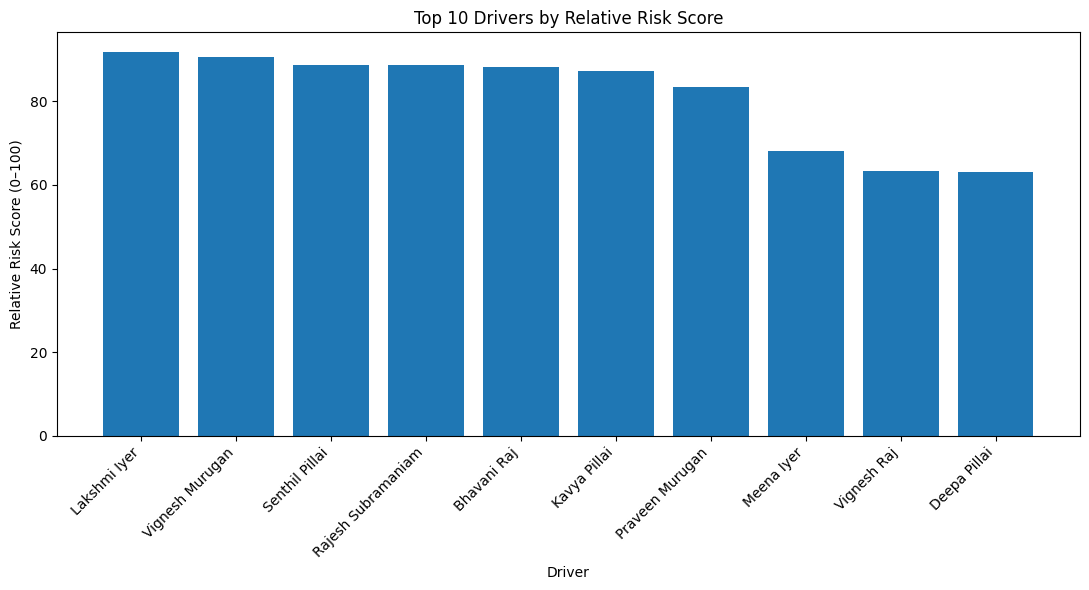

In [27]:
top10 = driver_dashboard.sort_values(
    "risk_score",
    ascending=False
).head(10)

plt.figure(figsize=(11, 6))

plt.bar(
    top10["Driver_Name"],
    top10["risk_score"]
)

plt.title("Top 10 Drivers by Relative Risk Score")
plt.xlabel("Driver")
plt.ylabel("Relative Risk Score (0–100)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

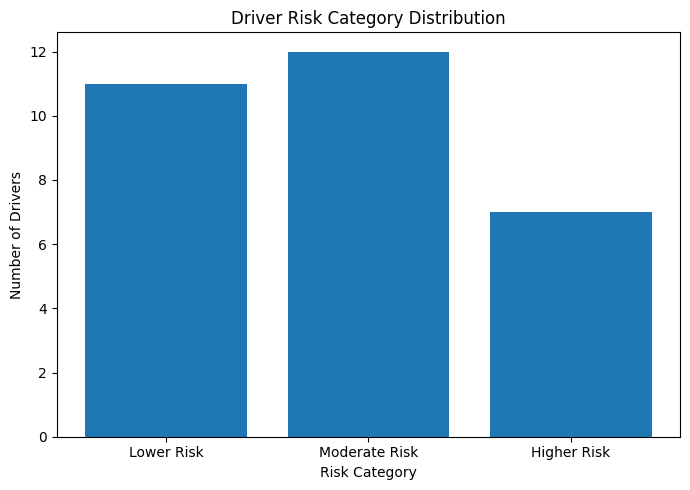

In [28]:
category_counts = (
    driver_dashboard["risk_category"]
    .value_counts()
    .reindex(["Lower Risk", "Moderate Risk", "Higher Risk"])
)

plt.figure(figsize=(7, 5))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Driver Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Drivers")

plt.tight_layout()
plt.show()

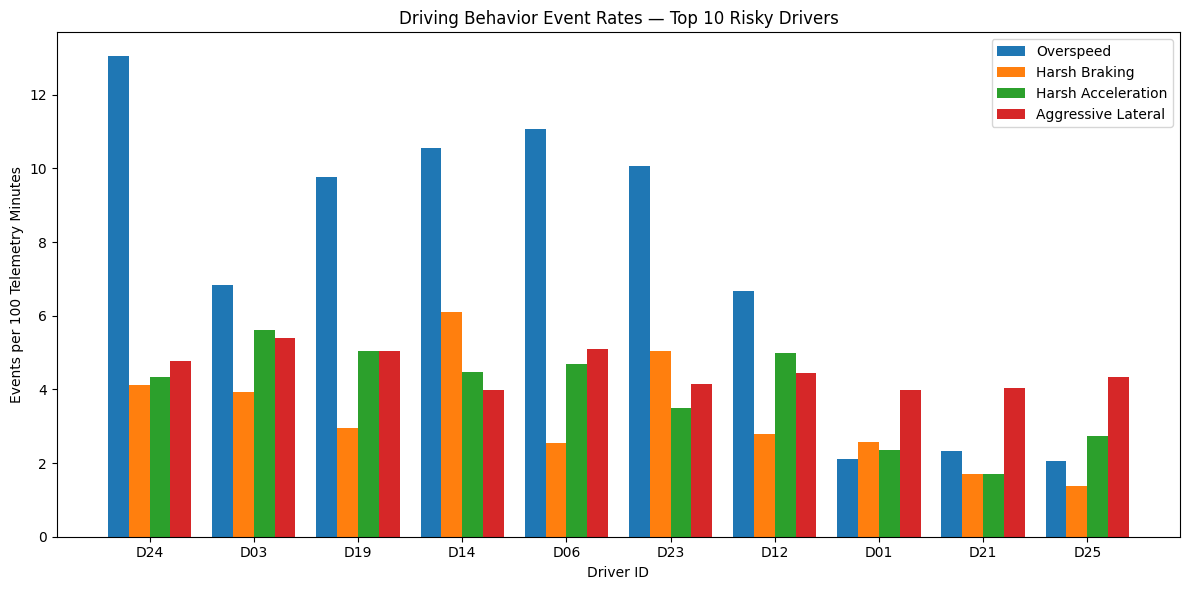

In [29]:
# Driver behavior breakdown: event rates per 100 telemetry minutes

behavior_metrics = [
    "overspeed_rate",
    "harsh_braking_rate",
    "harsh_acceleration_rate",
    "aggressive_lateral_rate"
]

top10_behavior = (
    driver_dashboard
    .sort_values("risk_score", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(12, 6))

x = range(len(top10_behavior))

plt.bar(
    [i - 0.3 for i in x],
    top10_behavior["overspeed_rate"],
    width=0.2,
    label="Overspeed"
)

plt.bar(
    [i - 0.1 for i in x],
    top10_behavior["harsh_braking_rate"],
    width=0.2,
    label="Harsh Braking"
)

plt.bar(
    [i + 0.1 for i in x],
    top10_behavior["harsh_acceleration_rate"],
    width=0.2,
    label="Harsh Acceleration"
)

plt.bar(
    [i + 0.3 for i in x],
    top10_behavior["aggressive_lateral_rate"],
    width=0.2,
    label="Aggressive Lateral"
)

plt.xticks(
    x,
    top10_behavior["Driver_ID"]
)

plt.title("Driving Behavior Event Rates — Top 10 Risky Drivers")
plt.xlabel("Driver ID")
plt.ylabel("Events per 100 Telemetry Minutes")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
# Final driver dashboard table

driver_dashboard_final = (
    driver_dashboard[
        [
            "risk_rank",
            "Driver_ID",
            "Driver_Name",
            "Home_Hub",
            "risk_score",
            "risk_category",
            "overspeed_rate",
            "harsh_braking_rate",
            "harsh_acceleration_rate",
            "aggressive_lateral_rate"
        ]
    ]
    .sort_values("risk_rank")
    .reset_index(drop=True)
)

driver_dashboard_final

,risk_rank,Driver_ID,Driver_Name,Home_Hub,risk_score,risk_category,overspeed_rate,harsh_braking_rate,harsh_acceleration_rate,aggressive_lateral_rate
0,1,D24,Lakshmi Iyer,Bellandur,91.9,Higher Risk,13.043478,4.130435,4.347826,4.782609
1,2,D03,Vignesh Murugan,Bommanahalli,90.5,Higher Risk,6.846473,3.941909,5.601660,5.394191
2,3,D19,Senthil Pillai,Attibele,88.8,Higher Risk,9.763314,2.958580,5.029586,5.029586
3,4,D14,Rajesh Subramaniam,Rajajinagar,88.6,Higher Risk,10.563380,6.103286,4.460094,3.990610
4,5,D06,Bhavani Raj,Electronic City,88.3,Higher Risk,11.063830,2.553191,4.680851,5.106383
5,6,D23,Kavya Pillai,Yeshwanthpur,87.2,Higher Risk,10.065646,5.032823,3.501094,4.157549
6,7,D12,Praveen Murugan,HSR Layout,83.4,Higher Risk,6.666667,2.777778,5.000000,4.444444
7,8,D01,Meena Iyer,Rajajinagar,68.1,Moderate Risk,2.107728,2.576112,2.341920,3.981265
8,9,D21,Vignesh Raj,MG Road,63.3,Moderate Risk,2.330508,1.694915,1.694915,4.025424
9,10,D25,Deepa Pillai,Rajajinagar,63.1,Moderate Risk,2.050114,1.366743,2.733485,4.328018


In [31]:
driver_dashboard_final.to_csv(
    "/content/drive/MyDrive/Vexar_Assignment/driver_dashboard_final.csv",
    index=False
)

print("Driver dashboard table saved successfully.")

Driver dashboard table saved successfully.


In [33]:
print(df.columns.tolist())

['Trip_ID', 'Driver_ID', 'Vehicle_ID', 'Timestamp', 'Latitude', 'Longitude', 'Speed_kmph', 'Accel_X_g', 'Accel_Y_g', 'Accel_Z_g', 'Gyro_X_dps', 'Gyro_Y_dps', 'Gyro_Z_dps', 'Trip_Date', 'Start_Time', 'End_Time', 'Duration_Min', 'Distance_KM', 'Avg_Speed_kmph', 'Max_Speed_kmph', 'Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Driver_Name', 'Age', 'Gender', 'License_Experience_Years', 'Date_Joined_Fleet', 'Primary_Vehicle_ID', 'Home_Hub', 'Vehicle_Type', 'Make', 'Model', 'Manufacture_Year', 'Registration_Date', 'Odometer_KM_Start_of_Week', 'Last_Service_Date', 'overspeed_event', 'harsh_acceleration', 'harsh_braking', 'aggressive_lateral_event']


In [34]:
# ==========================================
# VEHICLE HEALTH — TELEMETRY FEATURES
# ==========================================

# Find columns safely
def find_col(possible_names):
    normalized = {
        str(col).strip().lower(): col
        for col in df.columns
    }

    for name in possible_names:
        key = name.strip().lower()
        if key in normalized:
            return normalized[key]

    raise KeyError(
        f"Could not find any of: {possible_names}"
    )


vehicle_col = find_col([
    "Vehicle_ID",
    "vehicle_id"
])

trip_col = find_col([
    "Trip_ID",
    "trip_id"
])

accel_x_col = find_col([
    "Accel_X_g",
    "accel_x_g"
])

accel_y_col = find_col([
    "Accel_Y_g",
    "accel_y_g"
])

accel_z_col = find_col([
    "Accel_Z_g",
    "accel_z_g"
])

gyro_x_col = find_col([
    "Gyro_X_dps",
    "gyro_x_dps"
])

gyro_y_col = find_col([
    "Gyro_Y_dps",
    "gyro_y_dps"
])

gyro_z_col = find_col([
    "Gyro_Z_dps",
    "gyro_z_dps"
])


print("Using columns:")
print("Vehicle:", vehicle_col)
print("Trip:", trip_col)
print("Accel X:", accel_x_col)
print("Accel Y:", accel_y_col)
print("Accel Z:", accel_z_col)
print("Gyro X:", gyro_x_col)
print("Gyro Y:", gyro_y_col)
print("Gyro Z:", gyro_z_col)


# Absolute sensor measures
df["abs_gyro_x"] = df[gyro_x_col].abs()
df["abs_gyro_y"] = df[gyro_y_col].abs()
df["abs_gyro_z"] = df[gyro_z_col].abs()

df["abs_accel_x"] = df[accel_x_col].abs()
df["abs_accel_y"] = df[accel_y_col].abs()

# Z acceleration should normally be close to 1g
df["accel_z_deviation"] = (
    df[accel_z_col] - 1.0
).abs()


# Fleet-relative extreme thresholds
gyro_x_threshold = df["abs_gyro_x"].quantile(0.99)
gyro_y_threshold = df["abs_gyro_y"].quantile(0.99)
gyro_z_threshold = df["abs_gyro_z"].quantile(0.99)

accel_x_threshold = df["abs_accel_x"].quantile(0.99)
accel_y_threshold = df["abs_accel_y"].quantile(0.99)
accel_z_threshold = df["accel_z_deviation"].quantile(0.99)


print("\n=== SENSOR ANOMALY THRESHOLDS ===")
print("Gyro X:", round(gyro_x_threshold, 3))
print("Gyro Y:", round(gyro_y_threshold, 3))
print("Gyro Z:", round(gyro_z_threshold, 3))
print("Accel X:", round(accel_x_threshold, 3))
print("Accel Y:", round(accel_y_threshold, 3))
print("Accel Z deviation:", round(accel_z_threshold, 3))

Using columns:
Vehicle: Vehicle_ID
Trip: Trip_ID
Accel X: Accel_X_g
Accel Y: Accel_Y_g
Accel Z: Accel_Z_g
Gyro X: Gyro_X_dps
Gyro Y: Gyro_Y_dps
Gyro Z: Gyro_Z_dps

=== SENSOR ANOMALY THRESHOLDS ===
Gyro X: 5.83
Gyro Y: 5.69
Gyro Z: 46.912
Accel X: 0.702
Accel Y: 0.395
Accel Z deviation: 0.419


In [35]:
# ==========================================
# VEHICLE HEALTH — SENSOR ANOMALY FLAGS
# ==========================================

df["gyro_x_anomaly"] = (
    df["abs_gyro_x"] >= gyro_x_threshold
)

df["gyro_y_anomaly"] = (
    df["abs_gyro_y"] >= gyro_y_threshold
)

df["gyro_z_anomaly"] = (
    df["abs_gyro_z"] >= gyro_z_threshold
)

df["accel_x_anomaly"] = (
    df["abs_accel_x"] >= accel_x_threshold
)

df["accel_y_anomaly"] = (
    df["abs_accel_y"] >= accel_y_threshold
)

df["accel_z_anomaly"] = (
    df["accel_z_deviation"] >= accel_z_threshold
)


# A telemetry minute is considered anomalous
# if any sensor exceeds its fleet-relative 99th percentile.
df["any_sensor_anomaly"] = (
    df[
        [
            "gyro_x_anomaly",
            "gyro_y_anomaly",
            "gyro_z_anomaly",
            "accel_x_anomaly",
            "accel_y_anomaly",
            "accel_z_anomaly"
        ]
    ].any(axis=1)
)


print("=== SENSOR ANOMALY COUNTS ===")

print("Total telemetry observations:",
      len(df))

print("Any sensor anomaly:",
      int(df["any_sensor_anomaly"].sum()))

print("Gyro X anomalies:",
      int(df["gyro_x_anomaly"].sum()))

print("Gyro Y anomalies:",
      int(df["gyro_y_anomaly"].sum()))

print("Gyro Z anomalies:",
      int(df["gyro_z_anomaly"].sum()))

print("Accel X anomalies:",
      int(df["accel_x_anomaly"].sum()))

print("Accel Y anomalies:",
      int(df["accel_y_anomaly"].sum()))

print("Accel Z anomalies:",
      int(df["accel_z_anomaly"].sum()))

=== SENSOR ANOMALY COUNTS ===
Total telemetry observations: 12987
Any sensor anomaly: 620
Gyro X anomalies: 131
Gyro Y anomalies: 131
Gyro Z anomalies: 130
Accel X anomalies: 132
Accel Y anomalies: 131
Accel Z anomalies: 130


In [36]:
# ==========================================
# VEHICLE HEALTH — VEHICLE-LEVEL SUMMARY
# ==========================================

vehicle_sensor_health = (
    df.groupby(vehicle_col)
      .agg(
          telemetry_minutes=(trip_col, "size"),

          sensor_anomaly_minutes=(
              "any_sensor_anomaly",
              "sum"
          ),

          gyro_x_anomalies=(
              "gyro_x_anomaly",
              "sum"
          ),

          gyro_y_anomalies=(
              "gyro_y_anomaly",
              "sum"
          ),

          gyro_z_anomalies=(
              "gyro_z_anomaly",
              "sum"
          ),

          accel_x_anomalies=(
              "accel_x_anomaly",
              "sum"
          ),

          accel_y_anomalies=(
              "accel_y_anomaly",
              "sum"
          ),

          accel_z_anomalies=(
              "accel_z_anomaly",
              "sum"
          )
      )
      .reset_index()
)


# Percentage of each vehicle's telemetry
# that contained at least one anomaly.
vehicle_sensor_health["sensor_anomaly_rate"] = (
    vehicle_sensor_health["sensor_anomaly_minutes"]
    / vehicle_sensor_health["telemetry_minutes"]
    * 100
)


# Sort highest anomaly rate first
vehicle_sensor_health = (
    vehicle_sensor_health
    .sort_values(
        "sensor_anomaly_rate",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=== TOP VEHICLES BY SENSOR ANOMALY RATE ===")

display(
    vehicle_sensor_health.head(10)
)

=== TOP VEHICLES BY SENSOR ANOMALY RATE ===


,Vehicle_ID,telemetry_minutes,sensor_anomaly_minutes,gyro_x_anomalies,gyro_y_anomalies,gyro_z_anomalies,accel_x_anomalies,accel_y_anomalies,accel_z_anomalies,sensor_anomaly_rate
0,V02,443,41,20,20,3,1,2,24,9.255079
1,V19,374,32,6,6,6,6,7,10,8.556150
2,V24,416,34,7,4,4,9,9,4,8.173077
3,V14,446,32,3,4,8,13,4,3,7.174888
4,V13,431,29,9,6,6,6,6,7,6.728538
5,V12,360,24,3,3,7,6,7,2,6.666667
6,V23,555,37,8,4,9,13,5,8,6.666667
7,V01,427,26,7,1,9,8,4,3,6.088993
8,V25,439,25,8,7,5,1,7,9,5.694761
9,V10,486,27,7,11,6,2,2,7,5.555556


In [38]:
# ==========================================
# VEHICLE HEALTH — MASTER DATA + USAGE
# ==========================================

# Find the timestamp column safely
timestamp_col = find_col([
    "Timestamp",
    "timestamp"
])

print("Using timestamp column:", timestamp_col)


# ------------------------------------------
# Vehicle master data
# ------------------------------------------

vehicle_master = vehicles.copy()

vehicle_master["Registration_Date"] = pd.to_datetime(
    vehicle_master["Registration_Date"],
    errors="coerce"
)

vehicle_master["Last_Service_Date"] = pd.to_datetime(
    vehicle_master["Last_Service_Date"],
    errors="coerce"
)


# Observation end date from telemetry
observation_end = pd.to_datetime(
    df[timestamp_col],
    errors="coerce"
).max()

print("Observation period ends:", observation_end)


# Vehicle age
vehicle_master["vehicle_age_years"] = (
    observation_end -
    vehicle_master["Registration_Date"]
).dt.days / 365.25


# Days since service
vehicle_master["days_since_service"] = (
    observation_end -
    vehicle_master["Last_Service_Date"]
).dt.days


# ------------------------------------------
# Vehicle usage from Trips
# ------------------------------------------

vehicle_usage = (
    trips.groupby("Vehicle_ID")
    .agg(
        trips_observed=("Trip_ID", "nunique"),
        weekly_distance_km=("Distance_KM", "sum"),
        avg_trip_distance_km=("Distance_KM", "mean"),
        total_trip_duration_min=("Duration_Min", "sum")
    )
    .reset_index()
)


# ------------------------------------------
# Combine vehicle information
# ------------------------------------------

vehicle_health = (
    vehicle_master[
        [
            "Vehicle_ID",
            "Vehicle_Type",
            "Make",
            "Model",
            "Manufacture_Year",
            "Registration_Date",
            "Odometer_KM_Start_of_Week",
            "Last_Service_Date",
            "vehicle_age_years",
            "days_since_service"
        ]
    ]
    .merge(
        vehicle_usage,
        on="Vehicle_ID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        vehicle_sensor_health,
        on="Vehicle_ID",
        how="left",
        validate="one_to_one"
    )
)


# Sort by sensor anomaly rate
vehicle_health = (
    vehicle_health
    .sort_values(
        "sensor_anomaly_rate",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Vehicle health dataset shape:", vehicle_health.shape)

display(
    vehicle_health[
        [
            "Vehicle_ID",
            "Make",
            "Model",
            "vehicle_age_years",
            "Odometer_KM_Start_of_Week",
            "days_since_service",
            "weekly_distance_km",
            "sensor_anomaly_rate"
        ]
    ].head(10)
)

Using timestamp column: Timestamp
Observation period ends: 2026-08-06 22:34:00
Vehicle health dataset shape: (30, 23)


,Vehicle_ID,Make,Model,vehicle_age_years,Odometer_KM_Start_of_Week,days_since_service,weekly_distance_km,sensor_anomaly_rate
0,V02,TVS,Raider,5.363450,46601,92,199.22,9.255079
1,V19,TVS,Ntorq,4.657084,17247,48,154.88,8.556150
2,V24,Honda,Activa,0.870637,22345,47,200.40,8.173077
3,V14,TVS,Raider,7.416838,5270,11,172.88,7.174888
4,V13,Bajaj,Pulsar,1.144422,22372,36,201.62,6.728538
5,V12,TVS,Ntorq,6.324435,31966,58,168.85,6.666667
6,V23,Suzuki,Access,5.522245,17821,51,244.54,6.666667
7,V01,Yamaha,Ray ZR,5.286790,22820,59,185.37,6.088993
8,V25,Suzuki,Access,1.760438,26280,34,206.60,5.694761
9,V10,TVS,Ntorq,7.534565,30162,36,215.13,5.555556


In [39]:
# ==========================================
# VEHICLE MAINTENANCE ATTENTION SCORE
# ==========================================

# Convert each metric to a 0-100 fleet-relative percentile
vehicle_health["sensor_score"] = percentile_0_100(
    vehicle_health["sensor_anomaly_rate"]
)

vehicle_health["odometer_score"] = percentile_0_100(
    vehicle_health["Odometer_KM_Start_of_Week"]
)

vehicle_health["service_score"] = percentile_0_100(
    vehicle_health["days_since_service"]
)

vehicle_health["age_score"] = percentile_0_100(
    vehicle_health["vehicle_age_years"]
)


# Weighted Maintenance Attention Score
vehicle_health["maintenance_attention_score"] = (
    vehicle_health["sensor_score"] * 0.50
    + vehicle_health["odometer_score"] * 0.20
    + vehicle_health["service_score"] * 0.15
    + vehicle_health["age_score"] * 0.15
).round(1)


# Classification
vehicle_health["maintenance_category"] = pd.cut(
    vehicle_health["maintenance_attention_score"],
    bins=[-np.inf, 40, 70, np.inf],
    labels=[
        "Lower Attention",
        "Monitor",
        "Higher Attention"
    ]
)


# Rank
vehicle_health["maintenance_rank"] = (
    vehicle_health["maintenance_attention_score"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)


# Final ranking
vehicle_health = (
    vehicle_health
    .sort_values(
        "maintenance_attention_score",
        ascending=False
    )
    .reset_index(drop=True)
)


print("=== VEHICLE MAINTENANCE ATTENTION RANKING ===")

display(
    vehicle_health[
        [
            "maintenance_rank",
            "Vehicle_ID",
            "Make",
            "Model",
            "maintenance_attention_score",
            "maintenance_category",
            "sensor_anomaly_rate",
            "Odometer_KM_Start_of_Week",
            "days_since_service",
            "vehicle_age_years"
        ]
    ]
)

=== VEHICLE MAINTENANCE ATTENTION RANKING ===


,maintenance_rank,Vehicle_ID,Make,Model,maintenance_attention_score,maintenance_category,sensor_anomaly_rate,Odometer_KM_Start_of_Week,days_since_service,vehicle_age_years
0,1,V02,TVS,Raider,94.8,Higher Attention,9.255079,46601,92,5.363450
1,2,V12,TVS,Ntorq,86.7,Higher Attention,6.666667,31966,58,6.324435
2,3,V19,TVS,Ntorq,81.6,Higher Attention,8.556150,17247,48,4.657084
3,4,V01,Yamaha,Ray ZR,78.3,Higher Attention,6.088993,22820,59,5.286790
4,5,V23,Suzuki,Access,77.9,Higher Attention,6.666667,17821,51,5.522245
5,6,V10,TVS,Ntorq,77.7,Higher Attention,5.555556,30162,36,7.534565
6,7,V24,Honda,Activa,73.6,Higher Attention,8.173077,22345,47,0.870637
7,8,V13,Bajaj,Pulsar,69.1,Monitor,6.728538,22372,36,1.144422
8,9,V25,Suzuki,Access,65.5,Monitor,5.694761,26280,34,1.760438
9,10,V14,TVS,Raider,62.3,Monitor,7.174888,5270,11,7.416838


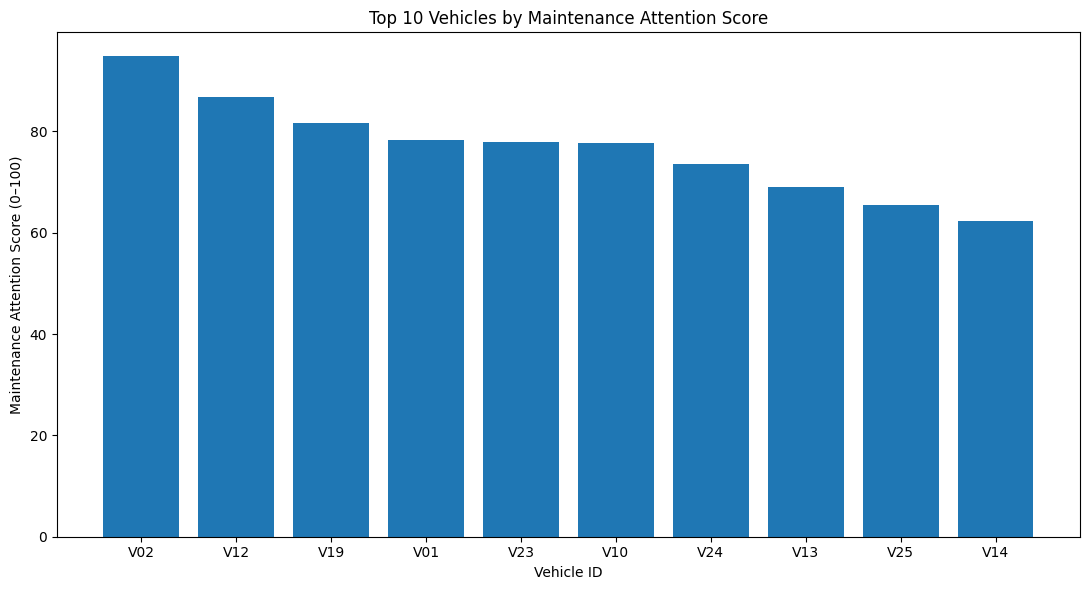

In [40]:
# ==========================================
# VEHICLE DASHBOARD — TOP ATTENTION VEHICLES
# ==========================================

top_attention = (
    vehicle_health
    .sort_values(
        "maintenance_attention_score",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(11, 6))

plt.bar(
    top_attention["Vehicle_ID"],
    top_attention["maintenance_attention_score"]
)

plt.title("Top 10 Vehicles by Maintenance Attention Score")
plt.xlabel("Vehicle ID")
plt.ylabel("Maintenance Attention Score (0–100)")

plt.tight_layout()
plt.show()

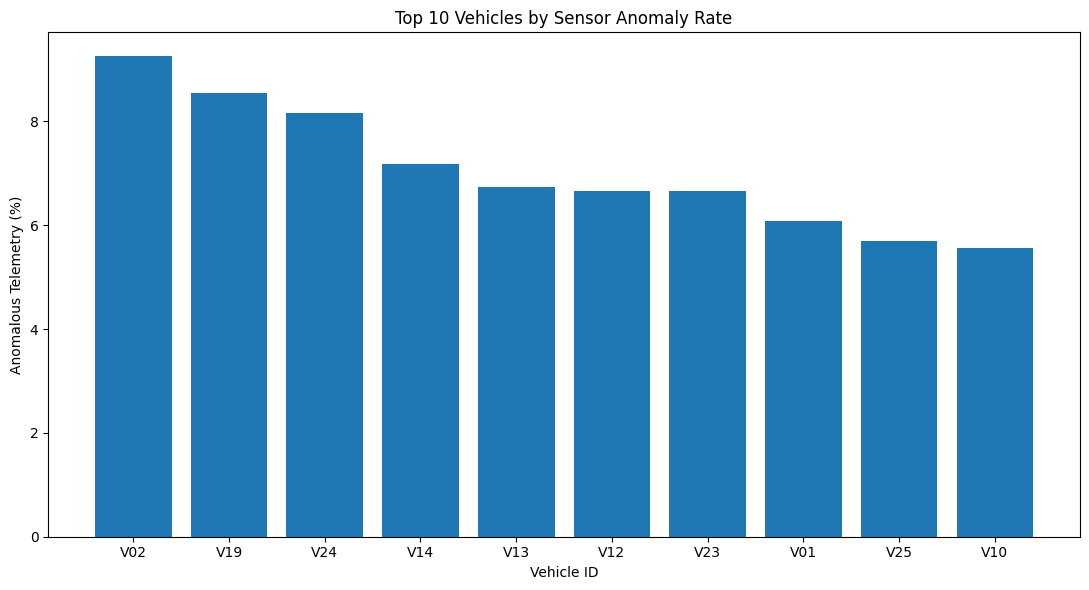

In [41]:
# ==========================================
# SENSOR ANOMALY RATE
# ==========================================

top_sensor = (
    vehicle_health
    .sort_values(
        "sensor_anomaly_rate",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(11, 6))

plt.bar(
    top_sensor["Vehicle_ID"],
    top_sensor["sensor_anomaly_rate"]
)

plt.title("Top 10 Vehicles by Sensor Anomaly Rate")
plt.xlabel("Vehicle ID")
plt.ylabel("Anomalous Telemetry (%)")

plt.tight_layout()
plt.show()

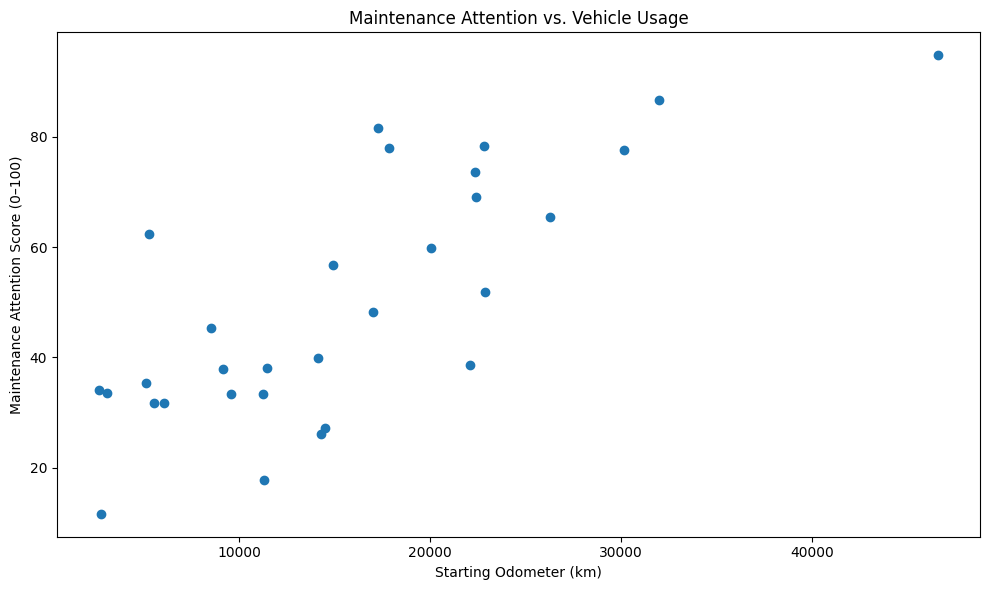

In [42]:
# ==========================================
# MAINTENANCE ATTENTION VS ODOMETER
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    vehicle_health["Odometer_KM_Start_of_Week"],
    vehicle_health["maintenance_attention_score"]
)

plt.xlabel("Starting Odometer (km)")
plt.ylabel("Maintenance Attention Score (0–100)")
plt.title("Maintenance Attention vs. Vehicle Usage")

plt.tight_layout()
plt.show()

In [43]:
# ==========================================
# FINAL VEHICLE HEALTH DASHBOARD TABLE
# ==========================================

vehicle_dashboard_final = (
    vehicle_health[
        [
            "maintenance_rank",
            "Vehicle_ID",
            "Make",
            "Model",
            "maintenance_attention_score",
            "maintenance_category",
            "sensor_anomaly_rate",
            "Odometer_KM_Start_of_Week",
            "days_since_service",
            "vehicle_age_years",
            "weekly_distance_km"
        ]
    ]
    .sort_values("maintenance_rank")
    .reset_index(drop=True)
)

display(vehicle_dashboard_final)

,maintenance_rank,Vehicle_ID,Make,Model,maintenance_attention_score,maintenance_category,sensor_anomaly_rate,Odometer_KM_Start_of_Week,days_since_service,vehicle_age_years,weekly_distance_km
0,1,V02,TVS,Raider,94.8,Higher Attention,9.255079,46601,92,5.363450,199.22
1,2,V12,TVS,Ntorq,86.7,Higher Attention,6.666667,31966,58,6.324435,168.85
2,3,V19,TVS,Ntorq,81.6,Higher Attention,8.556150,17247,48,4.657084,154.88
3,4,V01,Yamaha,Ray ZR,78.3,Higher Attention,6.088993,22820,59,5.286790,185.37
4,5,V23,Suzuki,Access,77.9,Higher Attention,6.666667,17821,51,5.522245,244.54
5,6,V10,TVS,Ntorq,77.7,Higher Attention,5.555556,30162,36,7.534565,215.13
6,7,V24,Honda,Activa,73.6,Higher Attention,8.173077,22345,47,0.870637,200.40
7,8,V13,Bajaj,Pulsar,69.1,Monitor,6.728538,22372,36,1.144422,201.62
8,9,V25,Suzuki,Access,65.5,Monitor,5.694761,26280,34,1.760438,206.60
9,10,V14,TVS,Raider,62.3,Monitor,7.174888,5270,11,7.416838,172.88


In [44]:
vehicle_dashboard_final.to_csv(
    "/content/drive/MyDrive/Vexar_Assignment/vehicle_dashboard_final.csv",
    index=False
)

print("Vehicle dashboard table saved successfully.")

Vehicle dashboard table saved successfully.


In [45]:
# ==========================================
# VEHICLE HEALTH VALIDATION
# ==========================================

odometer_corr = vehicle_health[
    [
        "Odometer_KM_Start_of_Week",
        "maintenance_attention_score"
    ]
].corr().iloc[0, 1]

print(
    "Correlation between odometer and maintenance attention:",
    round(odometer_corr, 3)
)

print("\nMaintenance category distribution:")
print(
    vehicle_health["maintenance_category"]
    .value_counts()
    .sort_index()
)

Correlation between odometer and maintenance attention: 0.772

Maintenance category distribution:
maintenance_category
Lower Attention     15
Monitor              8
Higher Attention     7
Name: count, dtype: int64


In [48]:
print([name for name in list(globals()) if "risk" in name.lower() or "driver" in name.lower()])

['drivers', 'driver_behavior', 'driver_ranking', 'driver_info', 'driver_dashboard', 'driver_dashboard_final', 'risk_df']


In [49]:
print(driver_ranking.columns.tolist())
print(driver_ranking.shape)

['Driver_ID', 'telemetry_minutes', 'trips', 'overspeed_events', 'harsh_acceleration_events', 'harsh_braking_events', 'aggressive_lateral_events', 'avg_speed_kmph', 'max_observed_speed_kmph', 'overspeed_rate', 'harsh_acceleration_rate', 'harsh_braking_rate', 'aggressive_lateral_rate', 'overspeed_score', 'braking_score', 'acceleration_score', 'lateral_score', 'risk_score', 'risk_category', 'risk_rank']
(30, 20)


In [50]:
print("\n".join(driver_ranking.columns.tolist()))

Driver_ID
telemetry_minutes
trips
overspeed_events
harsh_acceleration_events
harsh_braking_events
aggressive_lateral_events
avg_speed_kmph
max_observed_speed_kmph
overspeed_rate
harsh_acceleration_rate
harsh_braking_rate
aggressive_lateral_rate
overspeed_score
braking_score
acceleration_score
lateral_score
risk_score
risk_category
risk_rank


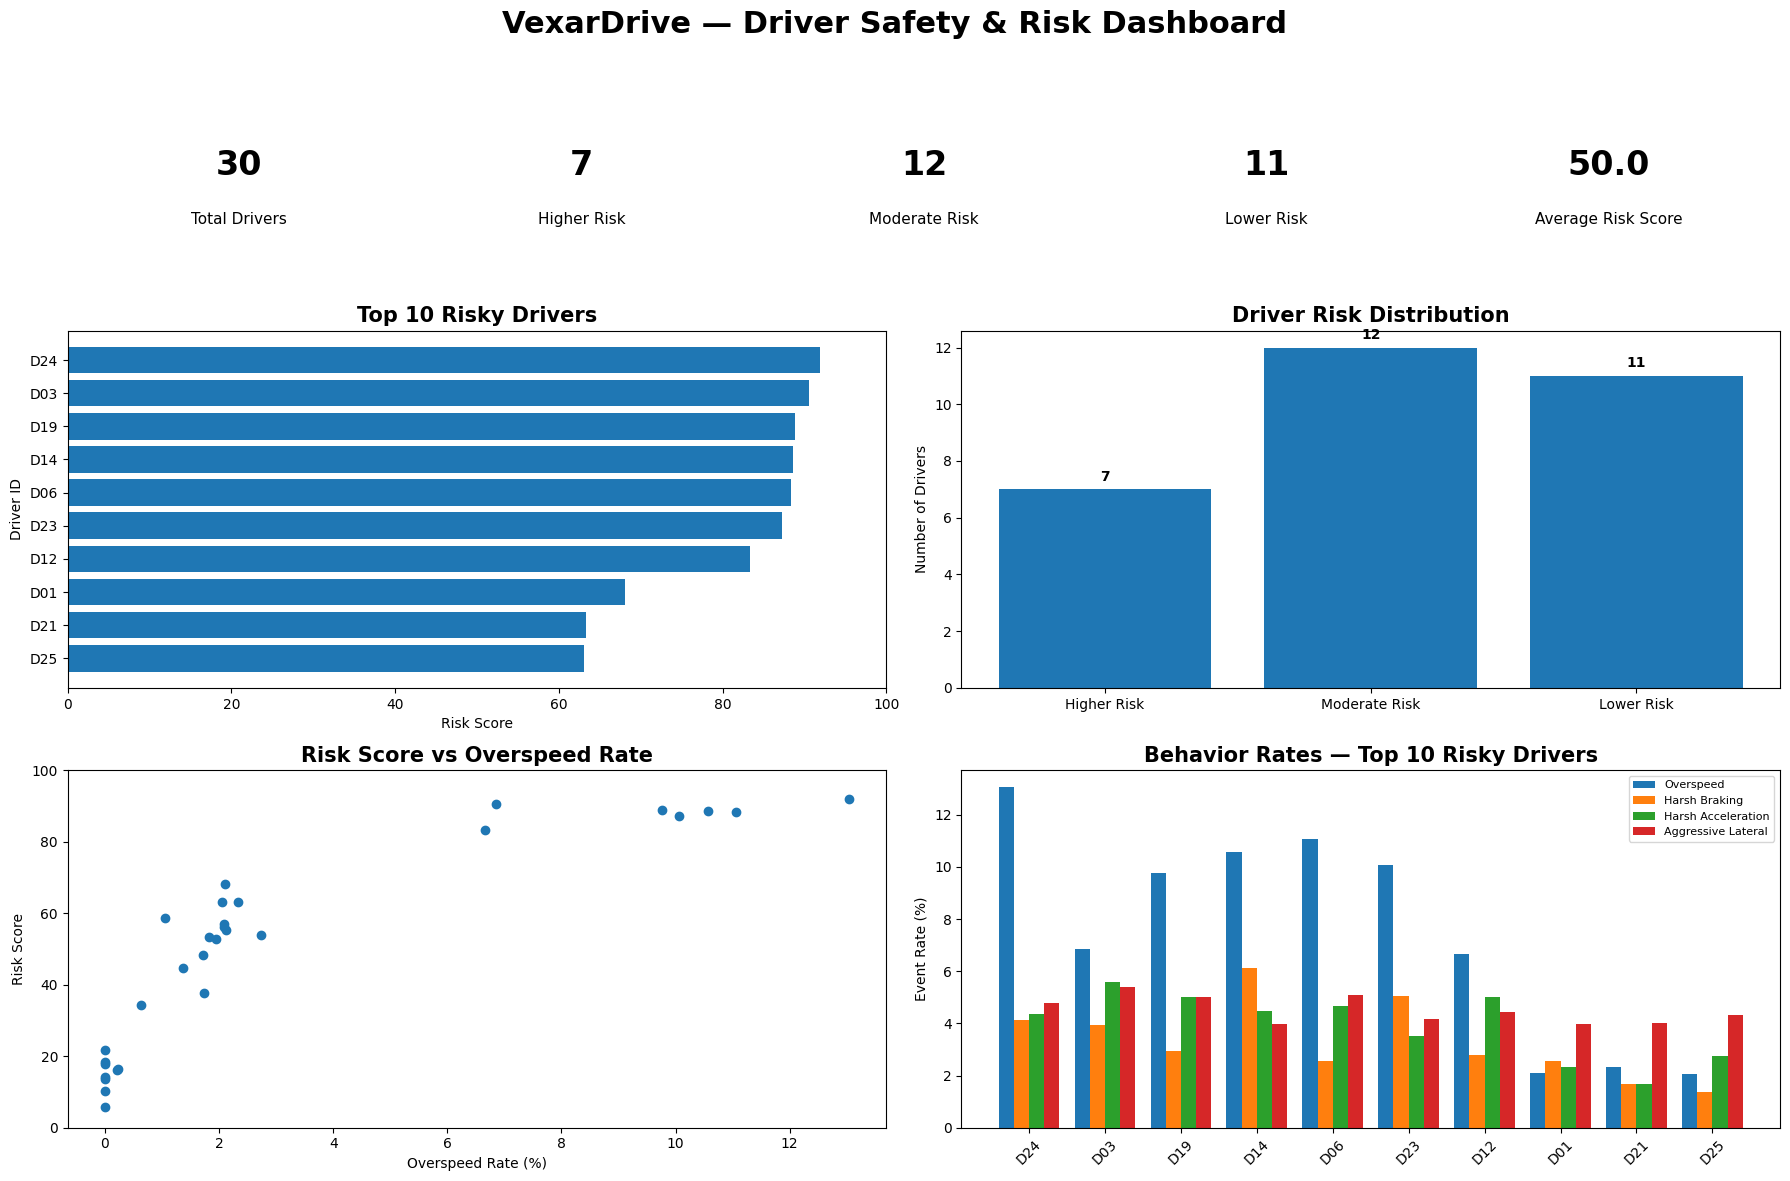

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Use the verified dataframe
dash_driver = driver_ranking.copy()

# Sort by risk score
dash_driver = dash_driver.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

# ==============================
# KPI VALUES
# ==============================

total_drivers = len(dash_driver)

higher_risk = (
    dash_driver["risk_category"] == "Higher Risk"
).sum()

moderate_risk = (
    dash_driver["risk_category"] == "Moderate Risk"
).sum()

lower_risk = (
    dash_driver["risk_category"] == "Lower Risk"
).sum()

avg_risk = dash_driver["risk_score"].mean()

# ==============================
# CREATE DASHBOARD
# ==============================

fig = plt.figure(figsize=(18, 12))

gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.8, 2, 2]
)

fig.suptitle(
    "VexarDrive — Driver Safety & Risk Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ==============================
# KPI SECTION
# ==============================

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")

kpis = [
    ("Total Drivers", total_drivers),
    ("Higher Risk", higher_risk),
    ("Moderate Risk", moderate_risk),
    ("Lower Risk", lower_risk),
    ("Average Risk Score", f"{avg_risk:.1f}")
]

x_positions = np.linspace(0.1, 0.9, len(kpis))

for x, (label, value) in zip(x_positions, kpis):

    ax_kpi.text(
        x,
        0.58,
        str(value),
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )

    ax_kpi.text(
        x,
        0.20,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

# ==============================
# TOP 10 RISKY DRIVERS
# ==============================

ax1 = fig.add_subplot(gs[1, 0])

top10 = (
    dash_driver
    .head(10)
    .sort_values("risk_score")
)

ax1.barh(
    top10["Driver_ID"],
    top10["risk_score"]
)

ax1.set_title(
    "Top 10 Risky Drivers",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("Risk Score")
ax1.set_ylabel("Driver ID")
ax1.set_xlim(0, 100)

# ==============================
# RISK CATEGORY DISTRIBUTION
# ==============================

ax2 = fig.add_subplot(gs[1, 1])

categories = [
    "Higher Risk",
    "Moderate Risk",
    "Lower Risk"
]

counts = [
    higher_risk,
    moderate_risk,
    lower_risk
]

ax2.bar(
    categories,
    counts
)

ax2.set_title(
    "Driver Risk Distribution",
    fontsize=15,
    fontweight="bold"
)

ax2.set_ylabel("Number of Drivers")

for i, count in enumerate(counts):

    ax2.text(
        i,
        count + 0.3,
        str(count),
        ha="center",
        fontweight="bold"
    )

# ==============================
# RISK VS OVERSPEED
# ==============================

ax3 = fig.add_subplot(gs[2, 0])

ax3.scatter(
    dash_driver["overspeed_rate"],
    dash_driver["risk_score"]
)

ax3.set_title(
    "Risk Score vs Overspeed Rate",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel("Overspeed Rate (%)")
ax3.set_ylabel("Risk Score")
ax3.set_ylim(0, 100)

# ==============================
# BEHAVIOR RATES
# ==============================

ax4 = fig.add_subplot(gs[2, 1])

top10 = dash_driver.head(10)

x = np.arange(len(top10))
width = 0.20

ax4.bar(
    x - 1.5 * width,
    top10["overspeed_rate"],
    width,
    label="Overspeed"
)

ax4.bar(
    x - 0.5 * width,
    top10["harsh_braking_rate"],
    width,
    label="Harsh Braking"
)

ax4.bar(
    x + 0.5 * width,
    top10["harsh_acceleration_rate"],
    width,
    label="Harsh Acceleration"
)

ax4.bar(
    x + 1.5 * width,
    top10["aggressive_lateral_rate"],
    width,
    label="Aggressive Lateral"
)

ax4.set_title(
    "Behavior Rates — Top 10 Risky Drivers",
    fontsize=15,
    fontweight="bold"
)

ax4.set_ylabel("Event Rate (%)")

ax4.set_xticks(x)

ax4.set_xticklabels(
    top10["Driver_ID"],
    rotation=45
)

ax4.legend(fontsize=8)

# ==============================
# FINALIZE
# ==============================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.savefig(
    "driver_safety_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [52]:
print([
    name for name in list(globals())
    if "vehicle" in name.lower() or "maintenance" in name.lower() or "sensor" in name.lower()
])

['vehicles', 'vehicle_id_col', 'vehicle_col', 'vehicle_sensor_health', 'vehicle_master', 'vehicle_usage', 'vehicle_health', 'top_sensor', 'vehicle_dashboard_final']


In [53]:
print(vehicle_health.columns.tolist())
print(vehicle_health.shape)

['Vehicle_ID', 'Vehicle_Type', 'Make', 'Model', 'Manufacture_Year', 'Registration_Date', 'Odometer_KM_Start_of_Week', 'Last_Service_Date', 'vehicle_age_years', 'days_since_service', 'trips_observed', 'weekly_distance_km', 'avg_trip_distance_km', 'total_trip_duration_min', 'telemetry_minutes', 'sensor_anomaly_minutes', 'gyro_x_anomalies', 'gyro_y_anomalies', 'gyro_z_anomalies', 'accel_x_anomalies', 'accel_y_anomalies', 'accel_z_anomalies', 'sensor_anomaly_rate', 'sensor_score', 'odometer_score', 'service_score', 'age_score', 'maintenance_attention_score', 'maintenance_category', 'maintenance_rank']
(30, 30)


In [54]:
print("\n".join(vehicle_health.columns.tolist()))

Vehicle_ID
Vehicle_Type
Make
Model
Manufacture_Year
Registration_Date
Odometer_KM_Start_of_Week
Last_Service_Date
vehicle_age_years
days_since_service
trips_observed
weekly_distance_km
avg_trip_distance_km
total_trip_duration_min
telemetry_minutes
sensor_anomaly_minutes
gyro_x_anomalies
gyro_y_anomalies
gyro_z_anomalies
accel_x_anomalies
accel_y_anomalies
accel_z_anomalies
sensor_anomaly_rate
sensor_score
odometer_score
service_score
age_score
maintenance_attention_score
maintenance_category
maintenance_rank


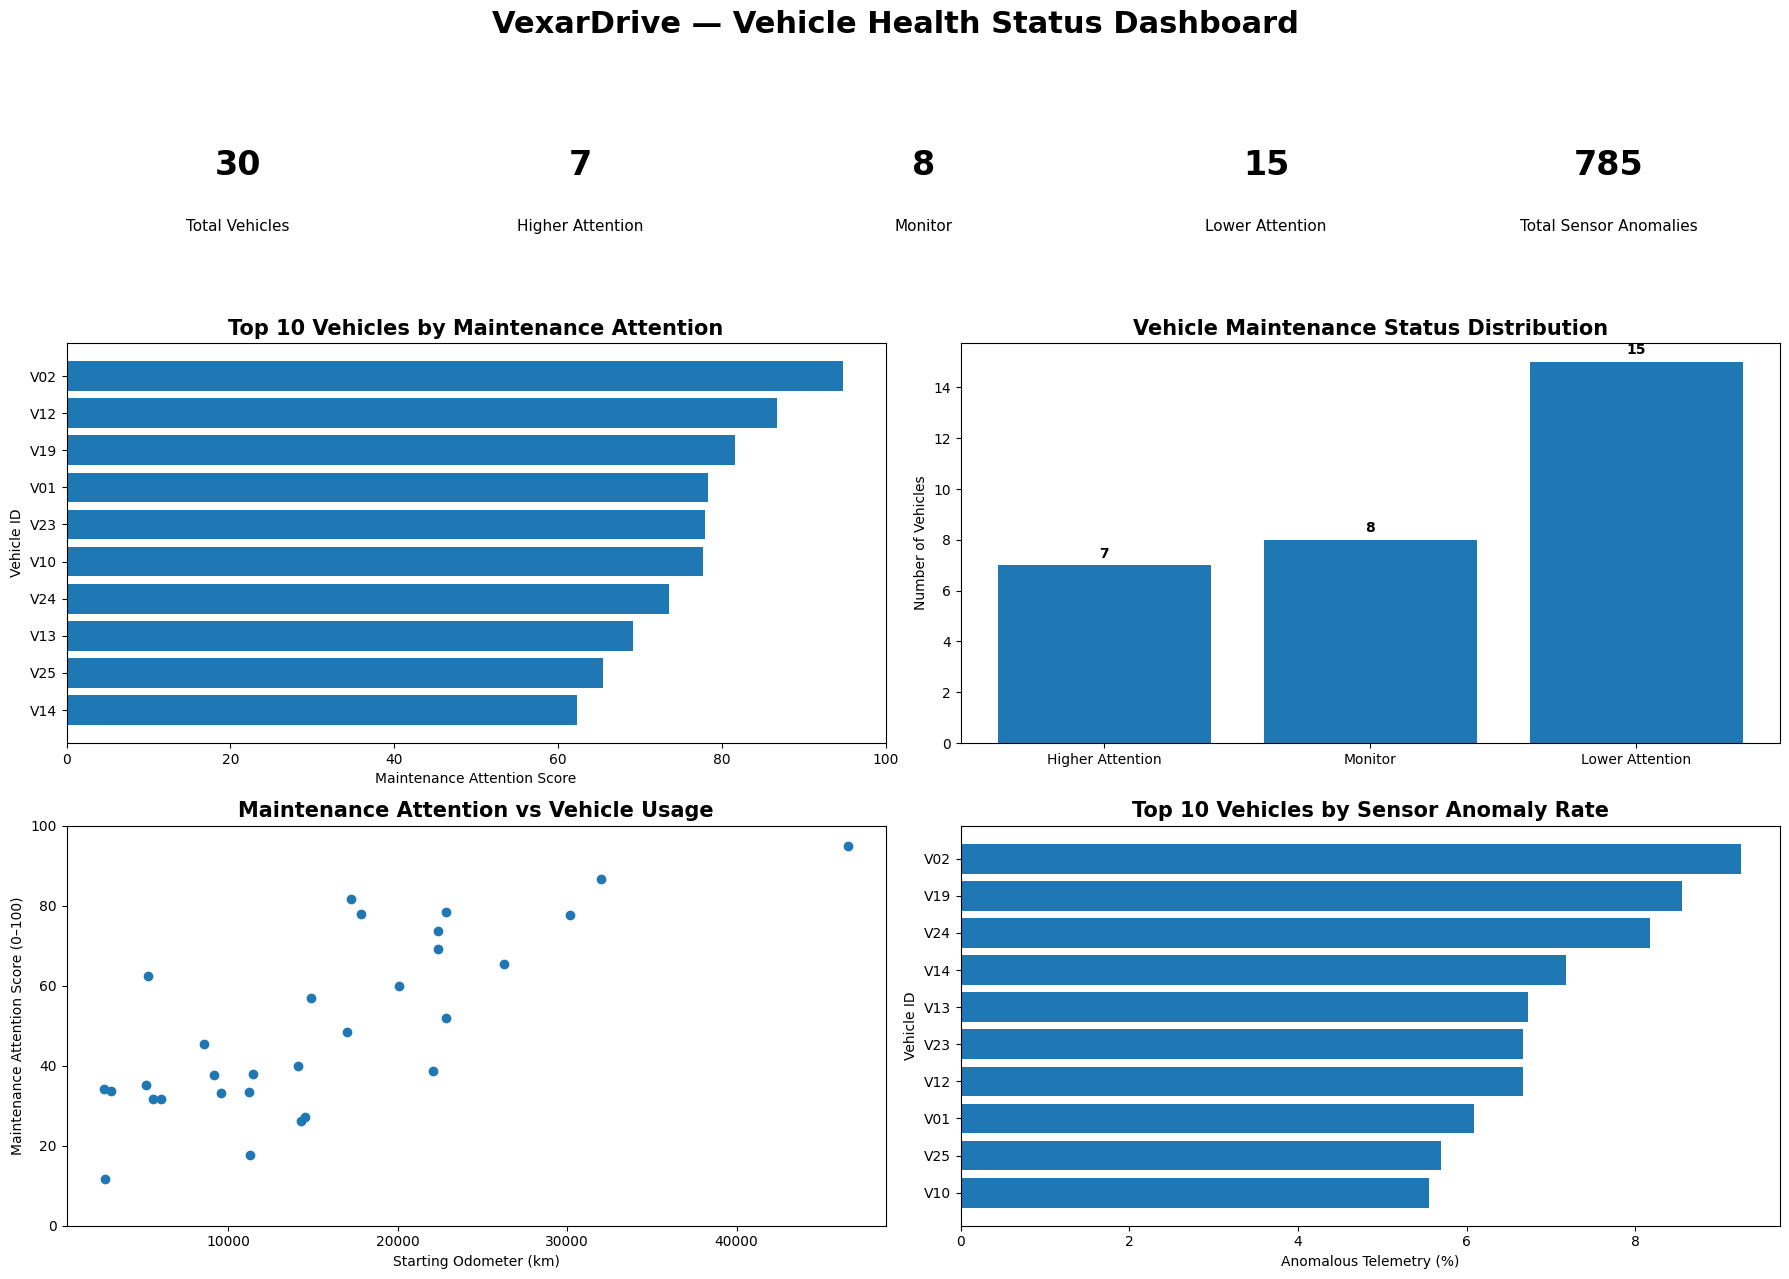

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# VEHICLE HEALTH STATUS DASHBOARD
# ============================================

# Use the verified vehicle-level dataframe
dash_vehicle = vehicle_health.copy()

# Sort by maintenance attention
dash_vehicle = dash_vehicle.sort_values(
    "maintenance_attention_score",
    ascending=False
).reset_index(drop=True)

# ============================================
# KPI VALUES
# ============================================

total_vehicles = len(dash_vehicle)

higher_attention = (
    dash_vehicle["maintenance_category"] == "Higher Attention"
).sum()

monitor_attention = (
    dash_vehicle["maintenance_category"] == "Monitor"
).sum()

lower_attention = (
    dash_vehicle["maintenance_category"] == "Lower Attention"
).sum()

avg_maintenance_score = (
    dash_vehicle["maintenance_attention_score"].mean()
)

total_sensor_anomalies = (
    dash_vehicle[
        [
            "gyro_x_anomalies",
            "gyro_y_anomalies",
            "gyro_z_anomalies",
            "accel_x_anomalies",
            "accel_y_anomalies",
            "accel_z_anomalies"
        ]
    ].sum().sum()
)

# ============================================
# CREATE DASHBOARD
# ============================================

fig = plt.figure(figsize=(18, 13))

gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.8, 2.1, 2.1]
)

fig.suptitle(
    "VexarDrive — Vehicle Health Status Dashboard",
    fontsize=22,
    fontweight="bold"
)

# ============================================
# KPI SECTION
# ============================================

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis("off")

kpis = [
    ("Total Vehicles", total_vehicles),
    ("Higher Attention", higher_attention),
    ("Monitor", monitor_attention),
    ("Lower Attention", lower_attention),
    ("Total Sensor Anomalies", int(total_sensor_anomalies))
]

x_positions = np.linspace(0.1, 0.9, len(kpis))

for x, (label, value) in zip(x_positions, kpis):

    ax_kpi.text(
        x,
        0.62,
        str(value),
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold"
    )

    ax_kpi.text(
        x,
        0.22,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

# ============================================
# TOP 10 VEHICLES BY MAINTENANCE ATTENTION
# ============================================

ax1 = fig.add_subplot(gs[1, 0])

top10_maintenance = (
    dash_vehicle
    .head(10)
    .sort_values("maintenance_attention_score")
)

ax1.barh(
    top10_maintenance["Vehicle_ID"],
    top10_maintenance["maintenance_attention_score"]
)

ax1.set_title(
    "Top 10 Vehicles by Maintenance Attention",
    fontsize=15,
    fontweight="bold"
)

ax1.set_xlabel("Maintenance Attention Score")
ax1.set_ylabel("Vehicle ID")

ax1.set_xlim(0, 100)

# ============================================
# MAINTENANCE CATEGORY DISTRIBUTION
# ============================================

ax2 = fig.add_subplot(gs[1, 1])

categories = [
    "Higher Attention",
    "Monitor",
    "Lower Attention"
]

counts = [
    higher_attention,
    monitor_attention,
    lower_attention
]

ax2.bar(
    categories,
    counts
)

ax2.set_title(
    "Vehicle Maintenance Status Distribution",
    fontsize=15,
    fontweight="bold"
)

ax2.set_ylabel("Number of Vehicles")

for i, count in enumerate(counts):

    ax2.text(
        i,
        count + 0.3,
        str(count),
        ha="center",
        fontweight="bold"
    )

# ============================================
# ODOMETER VS MAINTENANCE ATTENTION
# ============================================

ax3 = fig.add_subplot(gs[2, 0])

ax3.scatter(
    dash_vehicle["Odometer_KM_Start_of_Week"],
    dash_vehicle["maintenance_attention_score"]
)

ax3.set_title(
    "Maintenance Attention vs Vehicle Usage",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel("Starting Odometer (km)")
ax3.set_ylabel("Maintenance Attention Score (0–100)")

ax3.set_ylim(0, 100)

# ============================================
# TOP VEHICLES BY SENSOR ANOMALY RATE
# ============================================

ax4 = fig.add_subplot(gs[2, 1])

top10_sensor = (
    dash_vehicle
    .sort_values(
        "sensor_anomaly_rate",
        ascending=False
    )
    .head(10)
    .sort_values("sensor_anomaly_rate")
)

ax4.barh(
    top10_sensor["Vehicle_ID"],
    top10_sensor["sensor_anomaly_rate"]
)

ax4.set_title(
    "Top 10 Vehicles by Sensor Anomaly Rate",
    fontsize=15,
    fontweight="bold"
)

ax4.set_xlabel("Anomalous Telemetry (%)")
ax4.set_ylabel("Vehicle ID")

# ============================================
# FINAL LAYOUT + SAVE
# ============================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.savefig(
    "vehicle_health_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [56]:
import os

# Create output folder
os.makedirs("outputs", exist_ok=True)

# 1. Final driver ranking
driver_ranking.to_csv(
    "outputs/driver_ranking.csv",
    index=False
)

# 2. Final vehicle health ranking
vehicle_health.to_csv(
    "outputs/vehicle_health_ranking.csv",
    index=False
)

# 3. Driver behavior summary
driver_behavior.to_csv(
    "outputs/driver_behavior_summary.csv",
    index=False
)

# 4. Vehicle sensor anomaly summary
vehicle_health[
    [
        "Vehicle_ID",
        "telemetry_minutes",
        "sensor_anomaly_minutes",
        "gyro_x_anomalies",
        "gyro_y_anomalies",
        "gyro_z_anomalies",
        "accel_x_anomalies",
        "accel_y_anomalies",
        "accel_z_anomalies",
        "sensor_anomaly_rate"
    ]
].to_csv(
    "outputs/vehicle_sensor_anomalies.csv",
    index=False
)

# 5. Event summary
event_summary.to_csv(
    "outputs/event_summary.csv",
    index=False
)

# Verify files
print("=== OUTPUT FILES ===")

for filename in sorted(os.listdir("outputs")):
    print(filename)

=== OUTPUT FILES ===
driver_behavior_summary.csv
driver_ranking.csv
event_summary.csv
vehicle_health_ranking.csv
vehicle_sensor_anomalies.csv


In [57]:
import shutil
import os

dashboard_path = "/content/drive/MyDrive/Vexar_Assignment/dashboards"
os.makedirs(dashboard_path, exist_ok=True)

shutil.copy(
    "driver_safety_dashboard.png",
    dashboard_path
)

shutil.copy(
    "vehicle_health_dashboard.png",
    dashboard_path
)

print("Dashboard images saved to Google Drive:")
print(os.listdir(dashboard_path))

Dashboard images saved to Google Drive:
['driver_safety_dashboard.png', 'vehicle_health_dashboard.png']
